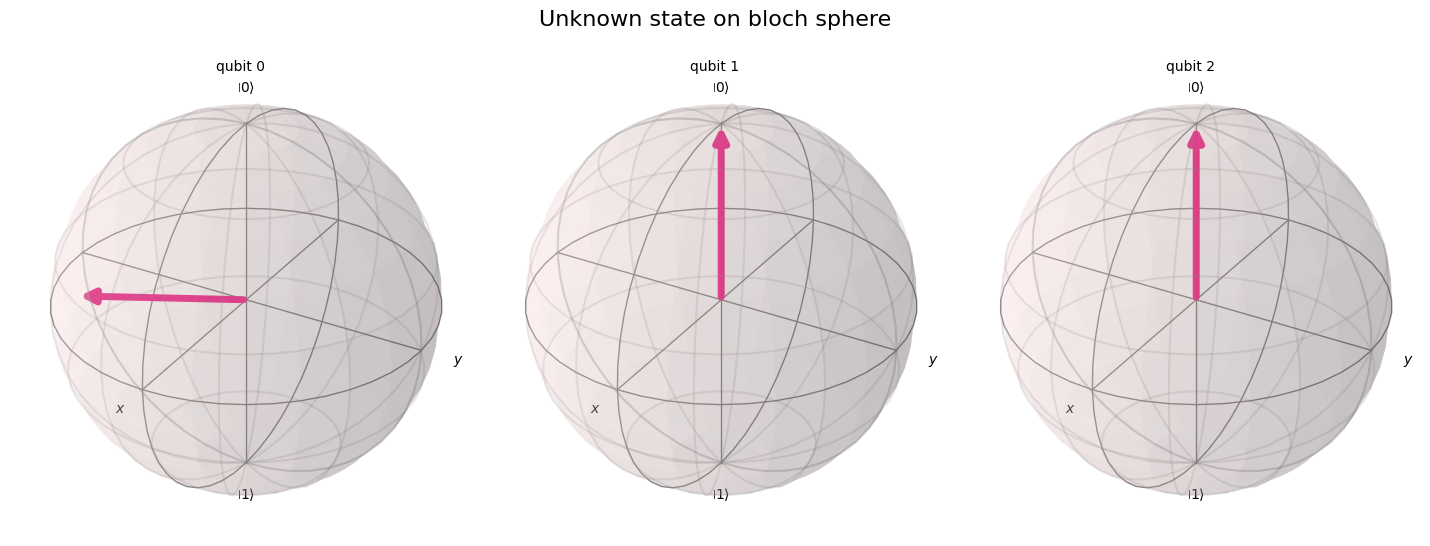

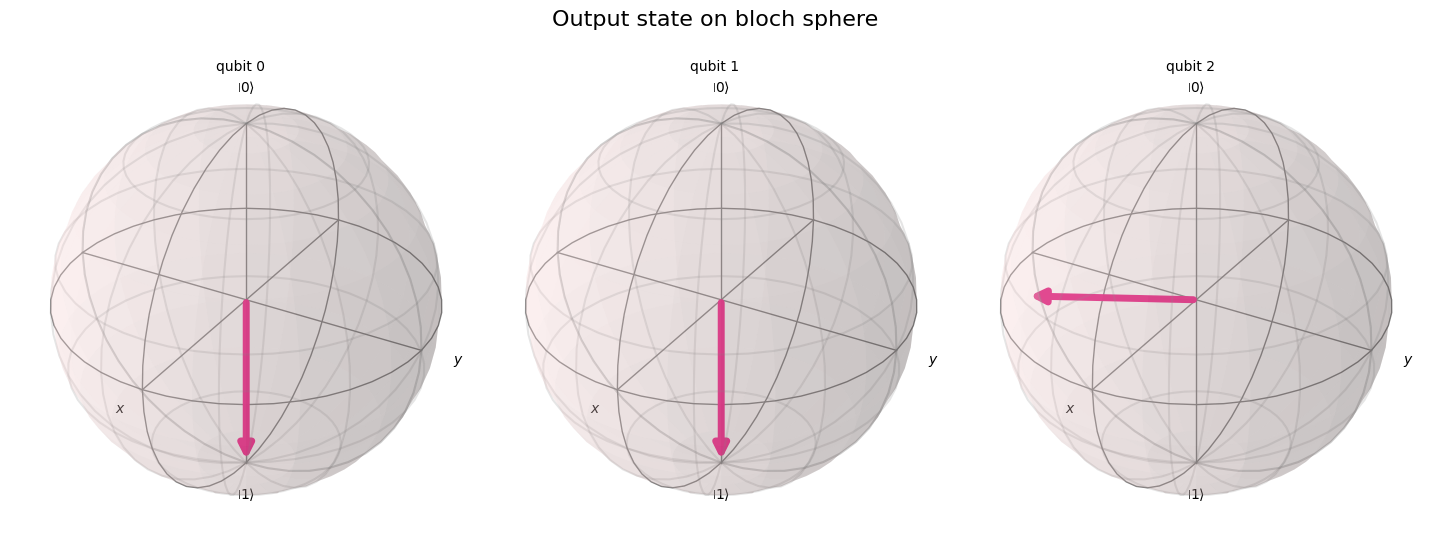

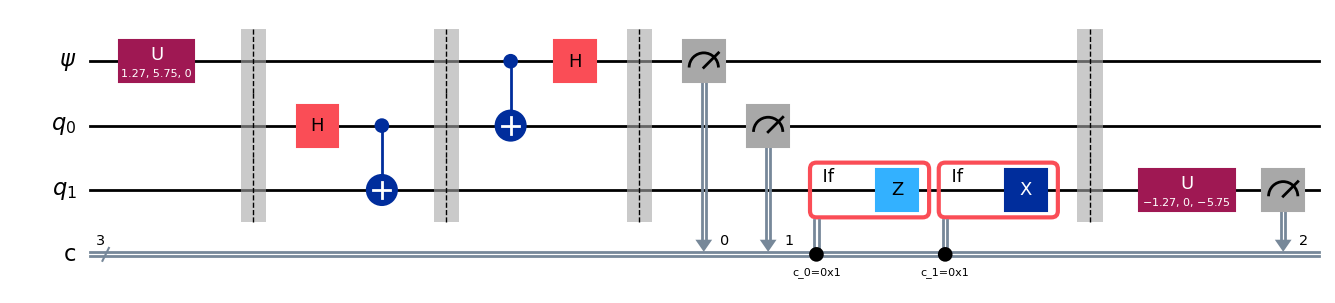

In [3]:
# https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/teleportation#4-quantum-teleportation

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
from qiskit_aer import StatevectorSimulator
import numpy as np

theta = np.random.uniform(0.0, 1.0) * np.pi  # from 0 to pi
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi

# Create 3-qubits circuit
qc = QuantumCircuit(
    q_psi := QuantumRegister(1, "\\psi"),
    q := QuantumRegister(2, "q"),
    c := ClassicalRegister(3, "c"),
)

# Create the unknown quantum state using the u-gate. Alice has this.
qc.u(theta, varphi, 0.0, q_psi)
qc.barrier()  # for visual separation

# Show the quantum state on bloch sphere
out_vector = Statevector(qc)
display(plot_bloch_multivector(out_vector, title="Unknown state on bloch sphere"))

# Alice and Bob are together in the same place and set up an entangled pair.
qc.h(q[0])
qc.cx(q[0], q[1])
qc.barrier()  # for visual separation.
# We can consider that Alice and Bob might move their qubits to different physical locations, now.

# Alice entangles the unknown state with her part of the e-bit, using the CNOT gate and H gate.
qc.cx(q_psi, q[0])
qc.h(q_psi)
qc.barrier()

# Alice measures the two qubits.
qc.measure(q_psi, c[0])
qc.measure(q[0], c[1])

# Alice sent the results to Bob. Bob applies correction
with qc.if_test((c[0], 1)):
    qc.z(q[1])
with qc.if_test((c[1], 1)):
    qc.x(q[1])
qc.barrier()

# Show the output state on bloch sphere
backend = StatevectorSimulator()
out_vector = backend.run(qc, shots=1).result().get_statevector()
display(plot_bloch_multivector(out_vector, title="Output state on bloch sphere"))

# Apply the inverse of u-gate to measure |0>
qc.u(theta, varphi, 0.0, q[1]).inverse()  # inverse of u(theta,varphi,0.0)
qc.measure(q[1], c[2])  # add measurement gate

qc.draw(output="mpl")

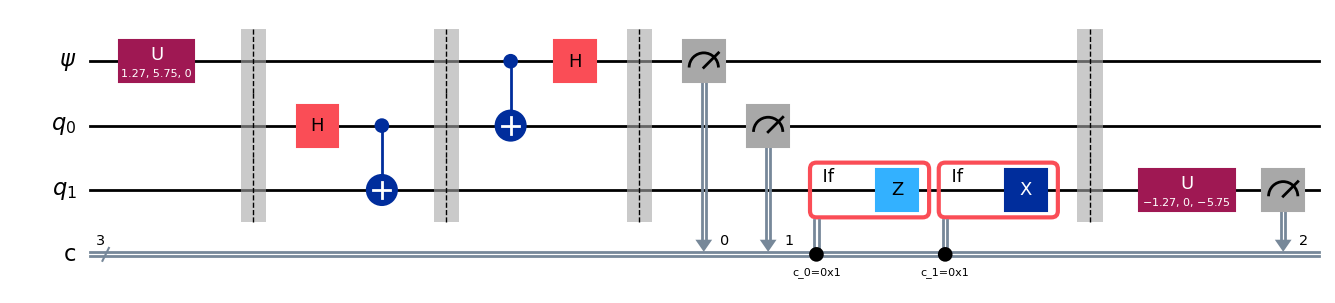

{'001': 262, '010': 256, '011': 245, '000': 261}


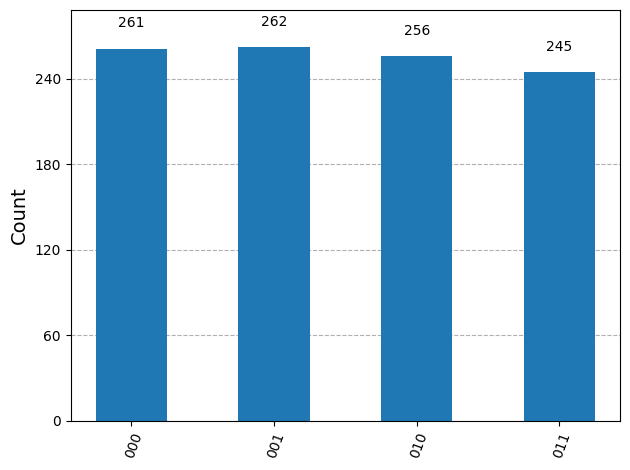

In [4]:
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2
from qiskit.visualization import plot_histogram

# Define backend
backend = AerSimulator()

# Transpile to backend
pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
isa_qc = pm.run(qc)

# Display the transpiled circuit
display(isa_qc.draw("mpl"))

# Run the job
sampler = SamplerV2(mode=backend)
job = sampler.run([isa_qc], shots=1024)
result = job.result()

# Extract counts data
counts = result[0].data.c.get_counts()
print(counts)

# Plot the counts in a histogram
plot_histogram(counts)